## Data Creation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from custom.models.feedforward_neural_network import FeedForwardNeuralNetwork
from custom.models.decision_tree import DecisionTree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


In [2]:
def create_data(n_features: int, n_samples: int, poly_expansion: bool, noise_std: float, random_seed: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    if random_seed:
        rng = np.random.RandomState(random_seed)
    else:
        rng = np.random
    X = rng.normal(0, 1, size=(n_samples, n_features))
    
    if poly_expansion:
        X_poly = X.copy()
        for i, deg in enumerate(range(1, n_features + 1)):
            X_poly[:,i] = X[:,i] ** deg
        y_poly = np.sum(X_poly, axis=1, keepdims=True) + rng.normal(0, noise_std, size=(n_samples, 1))
        return X, y_poly
    else:
        y = np.sum(X, axis=1, keepdims=True) + rng.normal(0, noise_std, size=(n_samples, 1))
        return X, y

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.base import RegressorMixin

def compare_regressors(models: list[tuple[RegressorMixin, RegressorMixin]], n_features_list: list[int], plot_data: bool = False) -> None:
    if plot_data:
        plt.figure(figsize=(6*len(n_features_list), 6*3))
    else:
        plt.figure(figsize=(6*len(n_features_list), 6*2))

    data = [create_data(n_features, 1000, False, 1) for n_features in n_features_list]
    data = [train_test_split(X, y, test_size=0.2) for X, y in data]

    data_train = [(X_train, y_train) for X_train, _, y_train, _ in data] 
    data_test = [(X_test, y_test) for _, X_test, _, y_test in data]

    if plot_data:
        for i, (n_features, (X, y)) in enumerate(zip(n_features_list, data_train)):
            pca = PCA().fit(X)
            X_pca = pca.transform(X)

            plt.subplot(3, len(n_features_list), i + 1)
            plt.scatter(X_pca[:,0], X_pca[:,1], c=y, label=f'Data Points (n_features={n_features})', s=10)
            plt.title(f'PCA Projection of Training Data with {n_features} Features')
        
    absolute_differences = []

    for i, (n_features, (X, y)) in enumerate(zip(n_features_list, data_test)):
        pca = PCA().fit(X)
        X_pca = pca.transform(X)

        X_train, y_train = data_train[i]
        our_model, skl_model = models[i]
        our_model.fit(X_train, y_train)
        skl_model.fit(X_train, y_train.ravel())

        y_pred_our = our_model.predict(X)
        y_pred_skl = skl_model.predict(X)

        absolute_differences.append(np.sum(np.abs(y_pred_our - y_pred_skl)))

        MSE_our = mean_squared_error(y, y_pred_our)
        MSE_skl = mean_squared_error(y, y_pred_skl)

        if plot_data:
            plt.subplot(3, len(n_features_list), len(n_features_list) + i + 1)
        else:
            plt.subplot(2, len(n_features_list), i + 1)
        plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_our, label=f'Our Model Predictions (n_features={n_features})', s=10)
        plt.title(f'PCA Projection of Our Model Predictions. MSE: {MSE_our:.4f}')
        if plot_data:
            plt.subplot(3, len(n_features_list), 2*len(n_features_list) + i + 1)
        else:
            plt.subplot(2, len(n_features_list), len(n_features_list) + i + 1)
        plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_skl, label=f'Sklearn Model Predictions (n_features={n_features})', s=10)
        plt.title(f'PCA Projection of Sklearn Model Predictions. MSE: {MSE_skl:.4f}')
        plt.tight_layout()
        
    mean_absolute_difference = np.mean(absolute_differences)
    print("Mean Absolute Difference between Our Model and Sklearn Model Predictions:", mean_absolute_difference)

Mean Absolute Difference between Our Model and Sklearn Model Predictions: 78.83792079938773


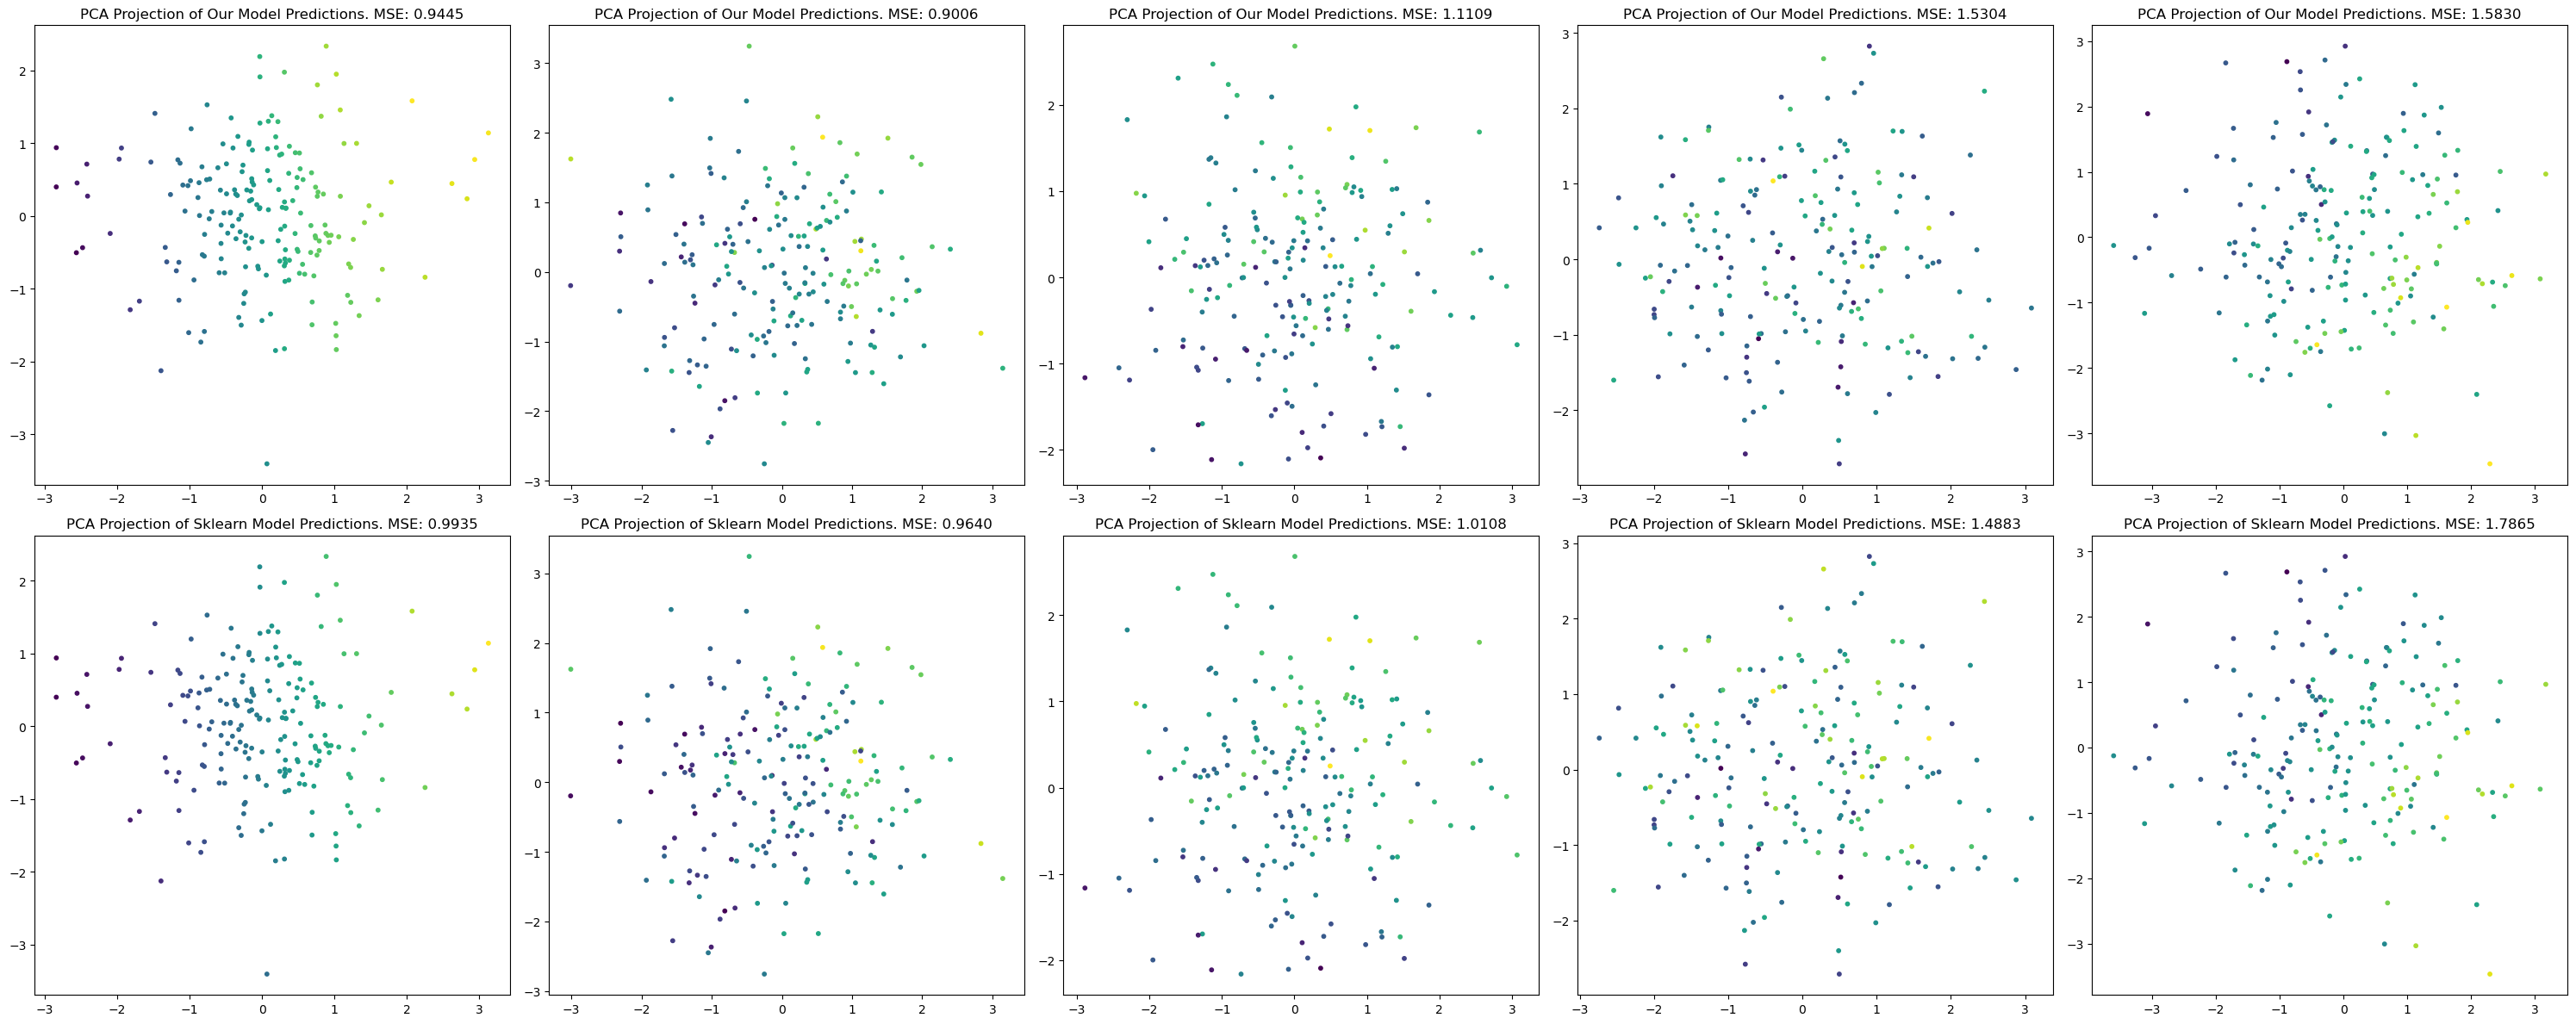

In [4]:
nn_models = [(FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=100, regression=True, auto_save=False),
            MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, early_stopping=True)) for _ in range(5)]
compare_regressors(nn_models, [2, 3, 5, 10, 20], plot_data=False)

In [5]:
def get_sine_data(n_samples=100):
    X = np.random.uniform(-np.pi, np.pi, (n_samples, 1))
    y = np.sin(X) + np.random.normal(0, 0.1, (n_samples, 1))
    return X, y, lambda x: np.sin(x)

def get_linear_data(n_samples=100):
    X = np.random.uniform(0, 10, (n_samples, 1))
    y = 2*X + 1 + np.random.normal(0, 0.5, (n_samples, 1))
    return X, y, lambda x: 2*x + 1

def get_quadratic_data(n_samples=100):
    X = np.random.uniform(0, 10, (n_samples, 1))
    y = 2*X*X + 1 + np.random.normal(0, 2, (n_samples, 1))
    return X, y, lambda x: 2*x*x + 1

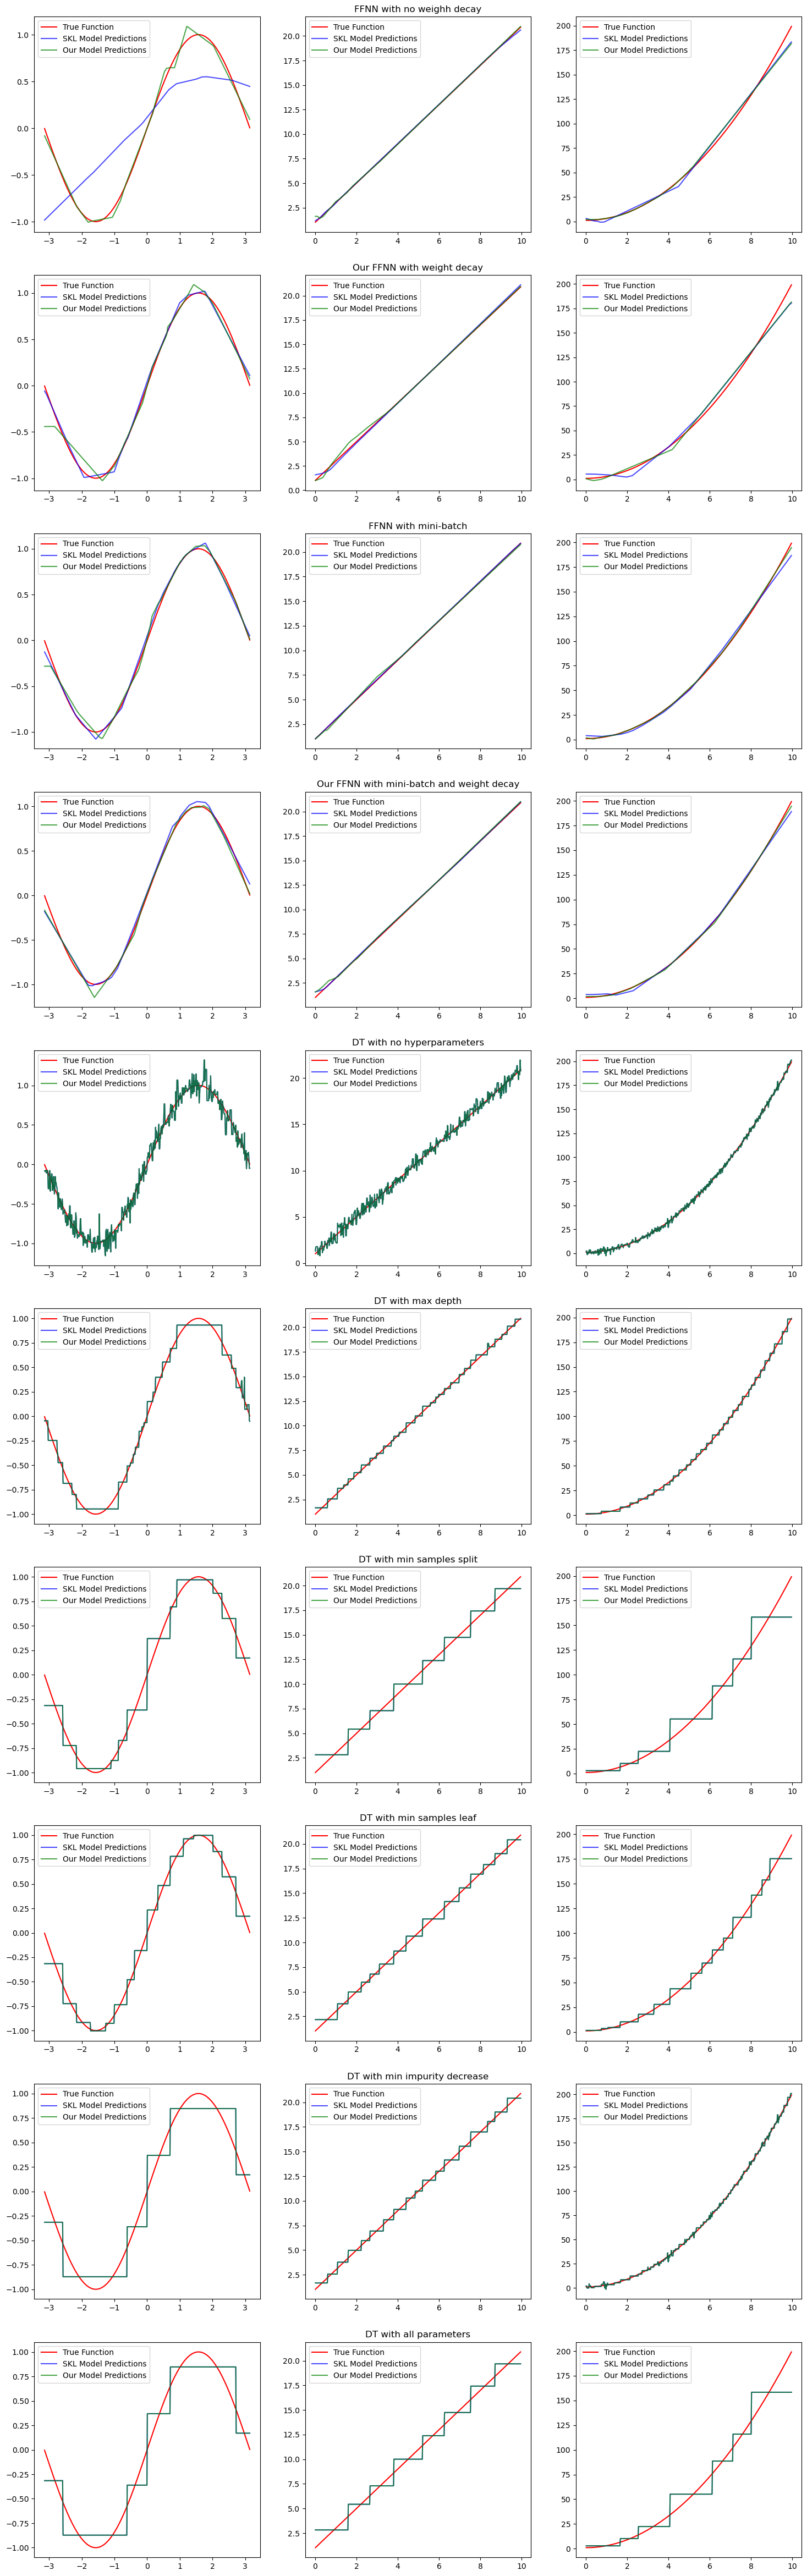

In [6]:
from typing import Callable

models = {
"FFNN with no weighh decay": (FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, regression=True, auto_save=False),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, early_stopping=True)),
"Our FFNN with weight decay": (FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, regularization_setting=(2, 0.01), regression=True, auto_save=False),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, early_stopping=True)),
"FFNN with mini-batch": (FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, batch_size=32, regression=True, auto_save=False),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, batch_size=32, early_stopping=True)),
"Our FFNN with mini-batch and weight decay": (FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, batch_size=32, regularization_setting=(2, 0.01), regression=True, auto_save=False),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, batch_size=32, early_stopping=True)),
"DT with no hyperparameters": (DecisionTree(), DecisionTreeRegressor()),
"DT with max depth": (DecisionTree(max_depth=5), DecisionTreeRegressor(max_depth=5)),
"DT with min samples split": (DecisionTree(min_to_split=100), DecisionTreeRegressor(min_samples_split=100)),
"DT with min samples leaf": (DecisionTree(min_samples_leaf=25), DecisionTreeRegressor(min_samples_leaf=25)),
"DT with min impurity decrease": (DecisionTree(min_impurity_decrease=0.01), DecisionTreeRegressor(min_impurity_decrease=0.01)),
"DT with all parameters": (DecisionTree(max_depth=5, min_to_split=100, min_samples_leaf=25, min_impurity_decrease=0.01), DecisionTreeRegressor(max_depth=5, min_samples_split=100, min_samples_leaf=25, min_impurity_decrease=0.01))
}
funcs = [get_sine_data, get_linear_data, get_quadratic_data]

def compare_regressors_on_functions(models: dict[str, tuple[RegressorMixin, RegressorMixin]], funcs: list[Callable]) -> None: # models tuple expect our model and sklearn model in that order
    fig, axs = plt.subplots(len(models), len(funcs), figsize=(6*len(funcs), 6*len(models)))

    for i, func in enumerate(funcs):
        X, y, true_function = func(n_samples=500)
        x_base = np.linspace(X.min(), X.max(), 500).flatten()

        for j, (model_cat, models_to_compare) in enumerate(models.items()):
            our_model, skl_model = models_to_compare
            our_model.fit(X, y)
            skl_model.fit(X, y.ravel())
            y_pred_our = our_model.predict(x_base.reshape(-1, 1))
            y_pred_skl = skl_model.predict(x_base.reshape(-1, 1))
            
            ax = axs[j, i] if len(models) > 1 else axs[i]
    
            ax.plot(x_base, true_function(x_base), color='red', label='True Function')
            ax.plot(x_base, y_pred_skl, color='blue', label='SKL Model Predictions', alpha=0.7)
            ax.plot(x_base, y_pred_our, color='green', label='Our Model Predictions', alpha=0.7)
            if i == 1:
                ax.set_title(model_cat)
            ax.legend()

compare_regressors_on_functions(models, funcs)

In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

def compare_to_null_model(model: tuple[str, RegressorMixin], random_seed: int | None = None) -> None:
    X, y = make_regression(n_samples=1000, n_features=5, noise=0.1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

    model_name, model = model

    null_model = DummyRegressor(strategy="mean")
    null_model.fit(X_train, y_train)
    y_pred_null = null_model.predict(X_test)

    model = model.fit(X_train, y_train)
    y_pred_model = model.predict(X_test)

    mae_null = mean_absolute_error(y_test, y_pred_null)
    mae_model = mean_absolute_error(y_test, y_pred_model)

    print(f"Mean Absolute Error of Null Model: {mae_null:.4f}")
    print(f"Mean Absolute Error of Our '{model_name}' Model: {mae_model:.4f}")
    if mae_model < mae_null:
        print(f"Our '{model_name}' model outperforms the null model.")
    else:
        print(f"Our '{model_name}' model does not outperform the null model.")
    print()

In [15]:
models = [(type_of_model, our_model) for type_of_model, (our_model, _) in models.items()]

for model in models:
    compare_to_null_model(model)

Mean Absolute Error of Null Model: 102.5859
Mean Absolute Error of Our 'FFNN with no weighh decay' Model: 10.8643
Our 'FFNN with no weighh decay' model outperforms the null model.

Mean Absolute Error of Null Model: 101.6935
Mean Absolute Error of Our 'Our FFNN with weight decay' Model: 56.3304
Our 'Our FFNN with weight decay' model outperforms the null model.

Mean Absolute Error of Null Model: 102.8015
Mean Absolute Error of Our 'FFNN with mini-batch' Model: 0.2217
Our 'FFNN with mini-batch' model outperforms the null model.

Mean Absolute Error of Null Model: 76.2185
Mean Absolute Error of Our 'Our FFNN with mini-batch and weight decay' Model: 0.2173
Our 'Our FFNN with mini-batch and weight decay' model outperforms the null model.

Mean Absolute Error of Null Model: 96.1224
Mean Absolute Error of Our 'DT with no hyperparameters' Model: 33.5794
Our 'DT with no hyperparameters' model outperforms the null model.

Mean Absolute Error of Null Model: 106.4858
Mean Absolute Error of Our 'D